# Phase 02: Descriptive & Diagnostic Data Analysis

Objective:

1. Examining the data for reporting and KPI tracking purposes.
2. Investigating data to identify trends, problems, and, etc. 

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from matplotlib.ticker import PercentFormatter

In [53]:
sns.set_theme(style="whitegrid", rc={"figure.figsize": (10, 6)})

In [54]:
frame = pd.read_csv('../data/intermediate/post-eda.csv', keep_default_na=False)
frame.head(5)

,customer_id,gender,age,married,number_of_dependents,tenure_in_months,number_of_referrals,city,offer,phone_service,...,average_monthly_gb_download,average_monthly_long_distance_charges,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,customer_status,churn_category,churn_reason
0,0002-ORFBO,Female,37,True,0,9,2,Frazier Park,None,True,...,16.0,42.39,65.6,593.30,0.0,0.0,381.51,Stayed,Still Subscribed,Still Subscribed
1,0004-TLHLJ,Male,50,False,0,4,0,Costa Mesa,Offer E,True,...,30.0,33.65,73.9,280.85,0.0,0.0,134.60,Churned,Competitor,Competitor had better devices
2,0011-IGKFF,Male,78,True,0,13,1,Martinez,Offer D,True,...,4.0,27.82,98.0,1237.85,0.0,0.0,361.66,Churned,Dissatisfaction,Product dissatisfaction
3,0013-EXCHZ,Female,75,True,0,3,3,Camarillo,None,True,...,11.0,7.38,83.9,267.40,0.0,0.0,22.14,Churned,Dissatisfaction,Network reliability
4,0013-MHZWF,Female,23,False,3,9,0,Midpines,Offer E,True,...,73.0,16.77,69.4,571.45,0.0,0.0,150.93,Stayed,Still Subscribed,Still Subscribed


In [55]:
churned = frame[frame['customer_status'] == 'Churned']
churned.head(5)

,customer_id,gender,age,married,number_of_dependents,tenure_in_months,number_of_referrals,city,offer,phone_service,...,average_monthly_gb_download,average_monthly_long_distance_charges,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,customer_status,churn_category,churn_reason
1,0004-TLHLJ,Male,50,False,0,4,0,Costa Mesa,Offer E,True,...,30.0,33.65,73.9,280.85,0.0,0.0,134.60,Churned,Competitor,Competitor had better devices
2,0011-IGKFF,Male,78,True,0,13,1,Martinez,Offer D,True,...,4.0,27.82,98.0,1237.85,0.0,0.0,361.66,Churned,Dissatisfaction,Product dissatisfaction
3,0013-EXCHZ,Female,75,True,0,3,3,Camarillo,None,True,...,11.0,7.38,83.9,267.40,0.0,0.0,22.14,Churned,Dissatisfaction,Network reliability
17,0022-TCJCI,Male,79,False,0,45,0,Daly City,None,True,...,17.0,10.67,62.7,2791.50,0.0,0.0,480.15,Churned,Dissatisfaction,Limited range of services
18,0023-HGHWL,Male,67,False,0,1,0,Morgan Hill,None,False,...,9.0,0.00,25.1,25.10,0.0,0.0,0.00,Churned,Competitor,Competitor made better offer


Text(0, 0.5, 'Number of Customers')

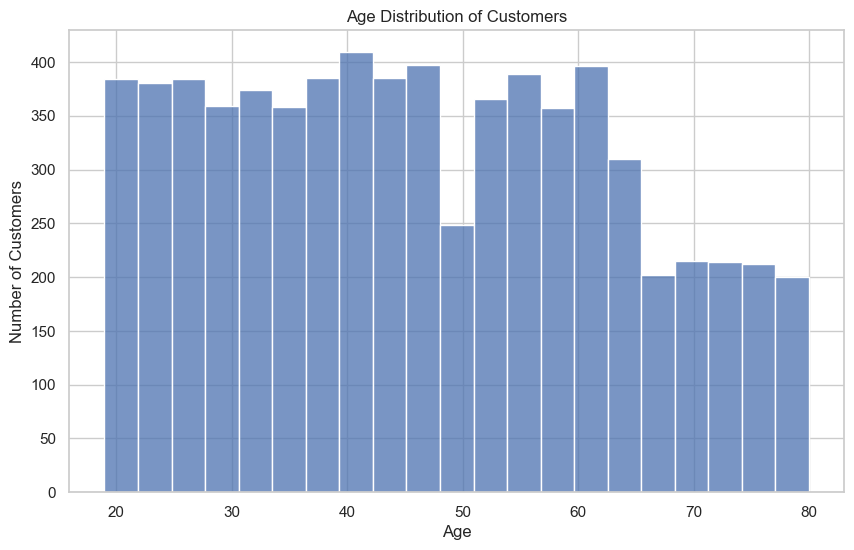

In [56]:
ageplt = sns.histplot(data=frame, x='age')
ageplt.set_title('Age Distribution of Customers')
ageplt.set_xlabel('Age')
ageplt.set_ylabel('Number of Customers')

Text(0.5, 0, 'Number of Customers')

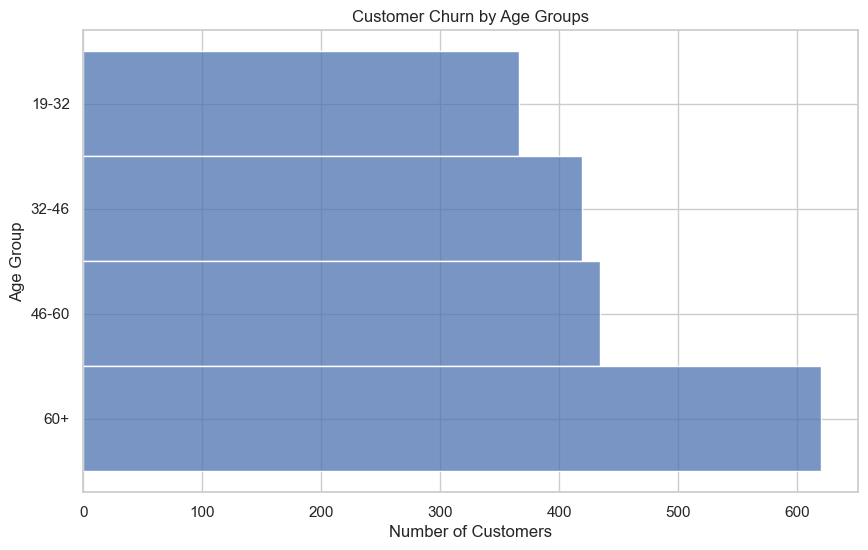

In [57]:
bins = [19, 32, 46, 60, float('inf')]
labels = ['19-32', '32-46', '46-60', '60+']

pseudo = churned.copy()
pseudo['age_group'] = pd.cut(pseudo['age'], bins=bins, labels=labels, right=False)

agplot = sns.histplot(data=pseudo, y='age_group')
agplot.set_title('Customer Churn by Age Groups')
agplot.set_ylabel('Age Group')
agplot.set_xlabel('Number of Customers')

While older age groups show higher churn rates, the 60+ segment has a significantly smaller sample size.

In [58]:
# monthly average revenue
tma_ldc = frame[frame['customer_status'] != 'Churned']['average_monthly_long_distance_charges'].sum()
tma_c = frame[frame['customer_status'] != 'Churned']['monthly_charge'].sum()

float(round(tma_ldc + tma_c, 2))

427695.66

Proof of the problem's existence:

In [59]:
round(len(churned) / len(frame) * 100, 2)

26.56

Text(0.5, 1.0, 'Tenure Distribution of Customers')

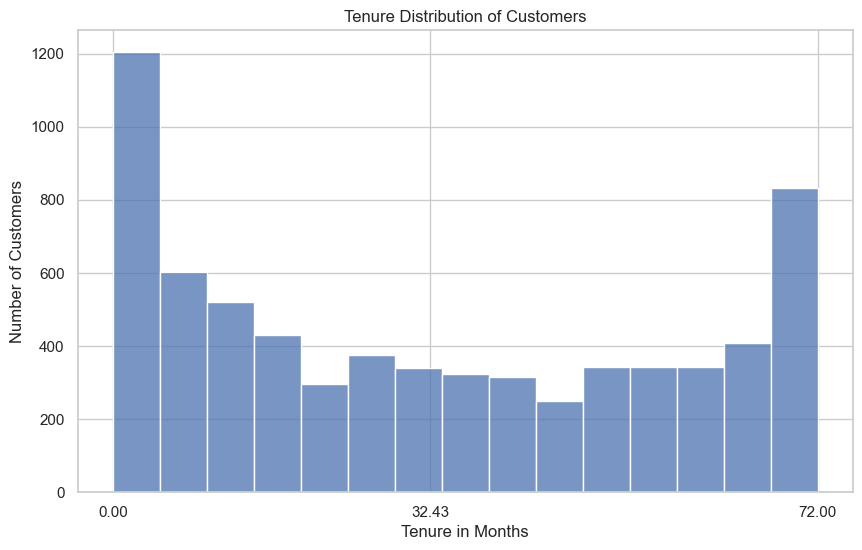

In [60]:
tenure = sns.histplot(x=frame['tenure_in_months'])
tenure.set_ylabel('Number of Customers')
tenure.set_xticks([frame['tenure_in_months'].min(), frame['tenure_in_months'].mean(), frame['tenure_in_months'].max()])
tenure.set_xlabel('Tenure in Months')
tenure.set_title('Tenure Distribution of Customers')

The chart indicates most customers are either new or churned early.

Text(0, 0.5, 'Number of Customers')

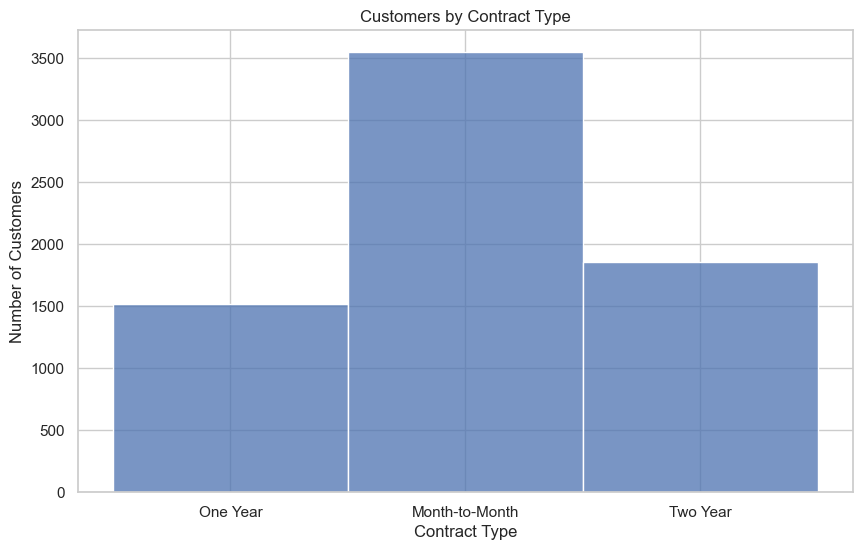

In [61]:
cplt = sns.histplot(data=frame, x='contract')
cplt.set_title('Customers by Contract Type')
cplt.set_xlabel('Contract Type')
cplt.set_ylabel('Number of Customers')

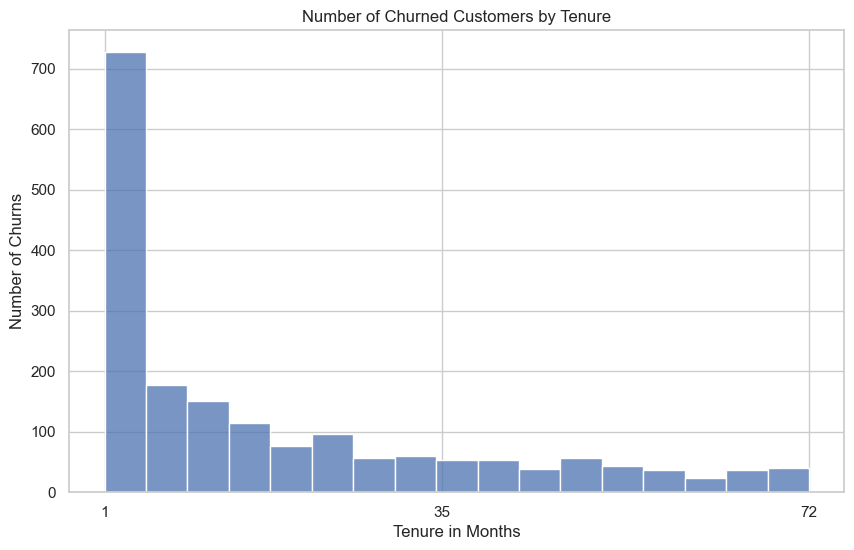

In [62]:
churntenure = sns.histplot(data=churned, x='tenure_in_months')
churntenure.set_ylabel('Number of Churns')
churntenure.set_xticks([churned['tenure_in_months'].min(), 35, churned['tenure_in_months'].max()])
churntenure.set_xlabel('Tenure in Months')
churntenure.set_title('Number of Churned Customers by Tenure')
plt.savefig('../data/graphs/by_tenure.png', bbox_inches='tight', dpi=300)

In [63]:
# percentage of churn for customers with tenure less than 7 months
round(len(frame[frame['tenure_in_months'] < 7]) * 100 / len(frame), 2)

20.87

In [64]:
round(len(churned[churned['tenure_in_months'] < 7]) * 100 / len(frame[frame['tenure_in_months'] < 7]), 2)

53.08

Text(0, 0.5, 'Number of Churns')

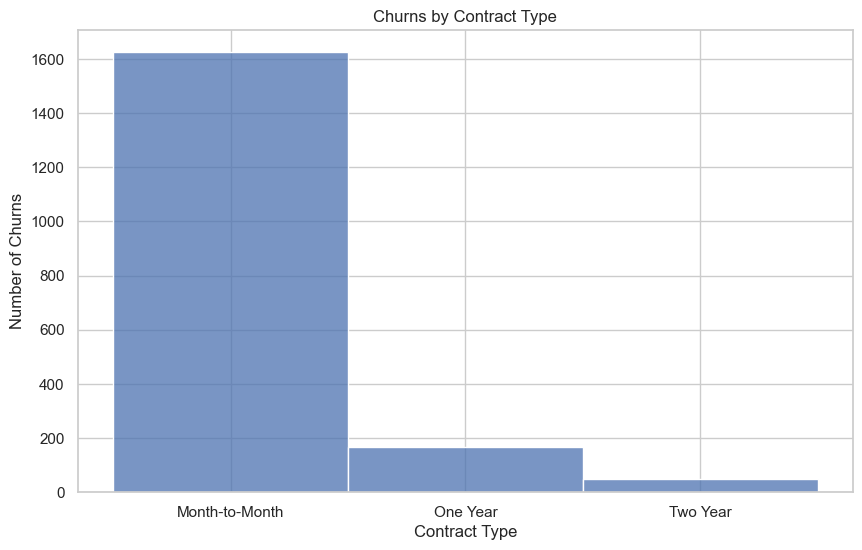

In [65]:
contplt = sns.histplot(data=churned, x='contract')
contplt.set_title('Churns by Contract Type')
contplt.set_xlabel('Contract Type')
contplt.set_ylabel('Number of Churns')

Over 53% of new customers churn within seven months, accounting for 20% of total churn. This indicates early-stage friction or a failure to demonstrate value. Let's now examine churn categories and reasons for further insight.

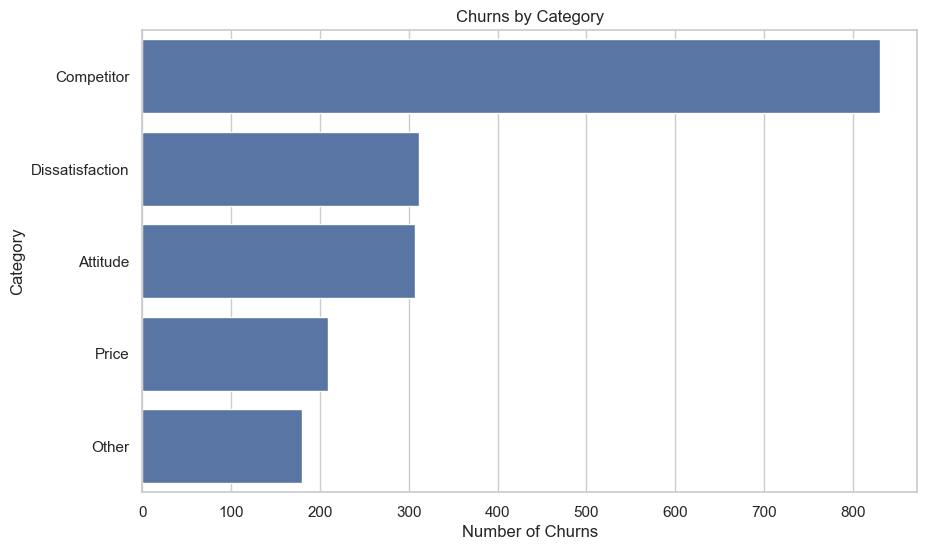

In [66]:
pseudo = churned.groupby('churn_category').agg(count=('age', 'count')).sort_values(by='count', ascending=False).reset_index()

catbar = sns.barplot(data=pseudo, x='count', y='churn_category')
catbar.set_title('Churns by Category')
catbar.set_xlabel('Number of Churns')
catbar.set_ylabel('Category')

plt.savefig('../data/graphs/by_category.png', bbox_inches='tight', dpi=300)

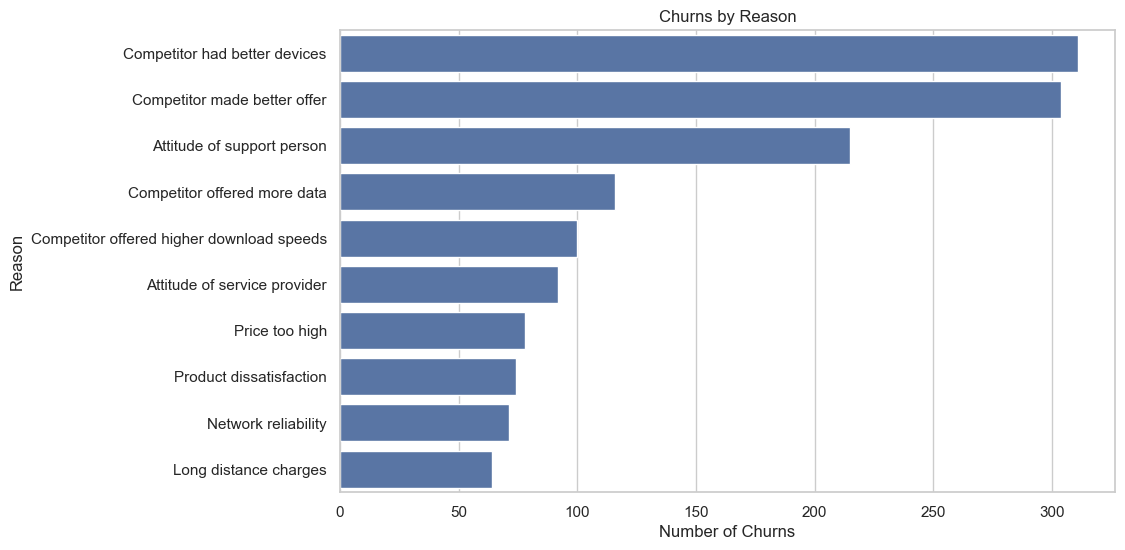

In [67]:
query = 'Don\'t know'

pseudo = (
    churned.query("churn_reason != @query")
    .groupby('churn_reason')
    .agg(count=('age', 'count'))
    .sort_values(by='count', ascending=False)
    .head(10)
    .reset_index()
)

catbar = sns.barplot(data=pseudo, x='count', y='churn_reason')
catbar.set_title('Churns by Reason')
catbar.set_xlabel('Number of Churns')
catbar.set_ylabel('Reason')

plt.savefig('../data/graphs/by_reason.png', bbox_inches='tight', dpi=300)

Data confirms competitor-driven churn, primarily fueled by superior device and service offers. Rivals are effectively poaching customers by bundling high-demand hardware with attractive plans to incentivize migration.

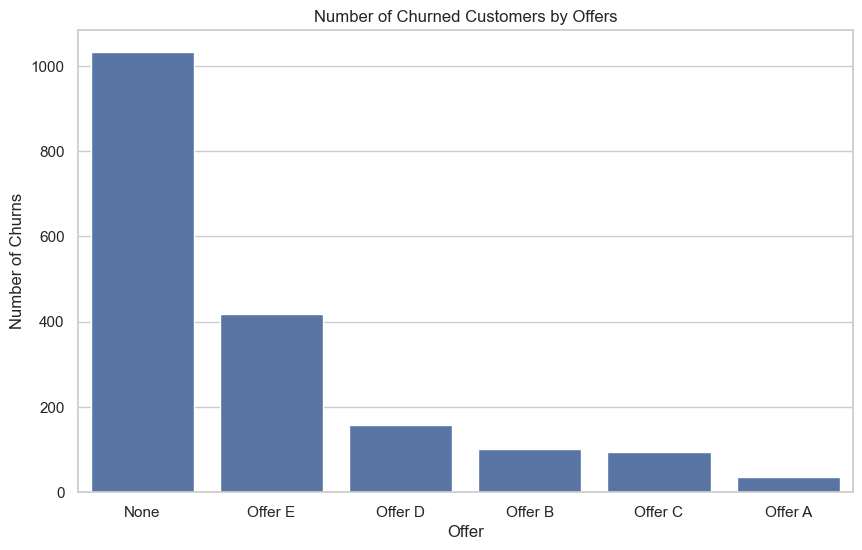

In [92]:
# count of churns by offers
source = churned.groupby('offer').agg(count=('age', 'count')).sort_values(by='count', ascending=False).reset_index()
offerplot = sns.barplot(data=source, x='offer', y='count')
offerplot.set_title('Number of Churned Customers by Offers')
offerplot.set_ylabel('Number of Churns')
offerplot.set_xlabel('Offer')
plt.savefig('../data/graphs/by_offers.png', bbox_inches='tight', dpi=300)

In [69]:
# checking if 'None' values caused by customers churning
len(frame.query("offer == 'None' & not customer_status == 'Churned'"))

2769

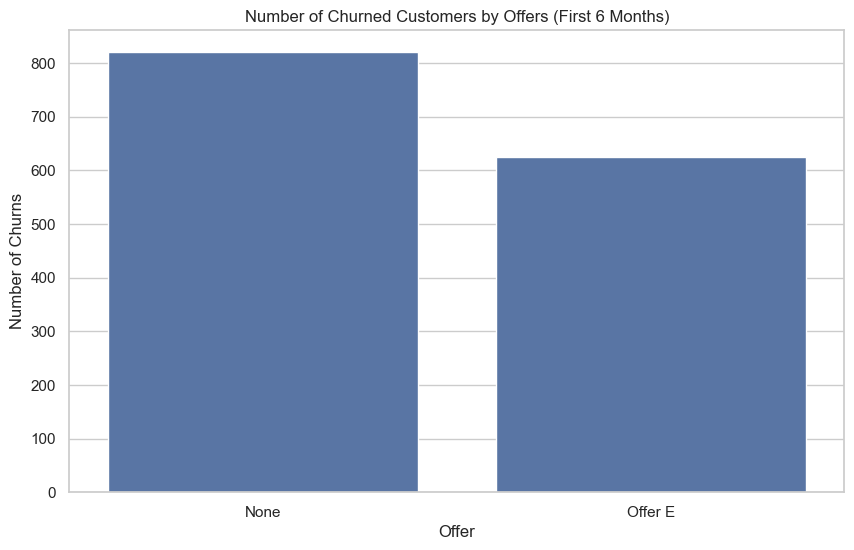

In [91]:
# count of churns by offers in first 7 months
source = frame[frame['tenure_in_months'] < 7].groupby('offer').agg(count=('age', 'count')).reset_index()
offerplot = sns.barplot(data=source, x='offer', y='count')
offerplot.set_title('Number of Churned Customers by Offers (First 6 Months)')
offerplot.set_ylabel('Number of Churns')
offerplot.set_xlabel('Offer')

plt.savefig('../data/graphs/by_offers_in_six.png', bbox_inches='tight', dpi=300)

Text(0.5, 0, 'Offer')

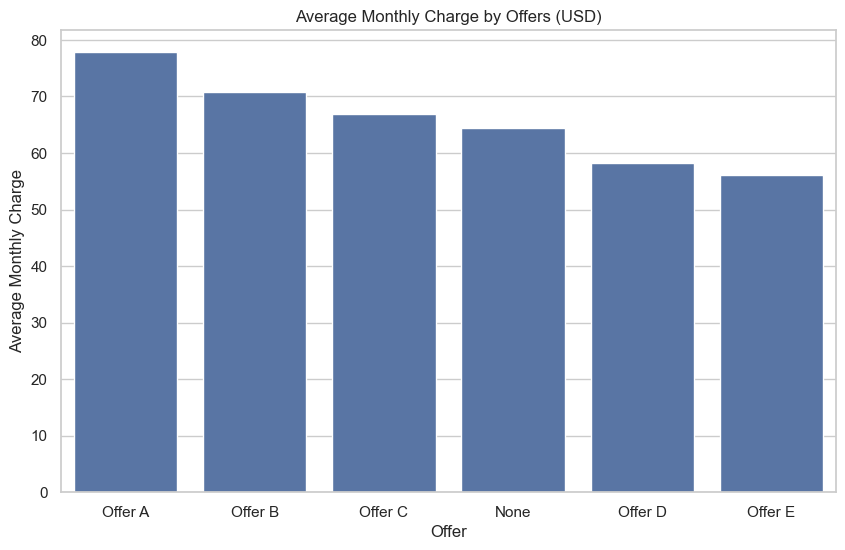

In [71]:
# average monthly charge by offers
source = frame.groupby('offer').agg(average_charge=('monthly_charge', 'mean')).sort_values(by='average_charge', ascending=False).round(2).reset_index()
offerplot = sns.barplot(data=source, x='offer', y='average_charge')
offerplot.set_title('Average Monthly Charge by Offers (USD)')
offerplot.set_ylabel('Average Monthly Charge')
offerplot.set_xlabel('Offer')

Text(0.5, 0, 'Offer')

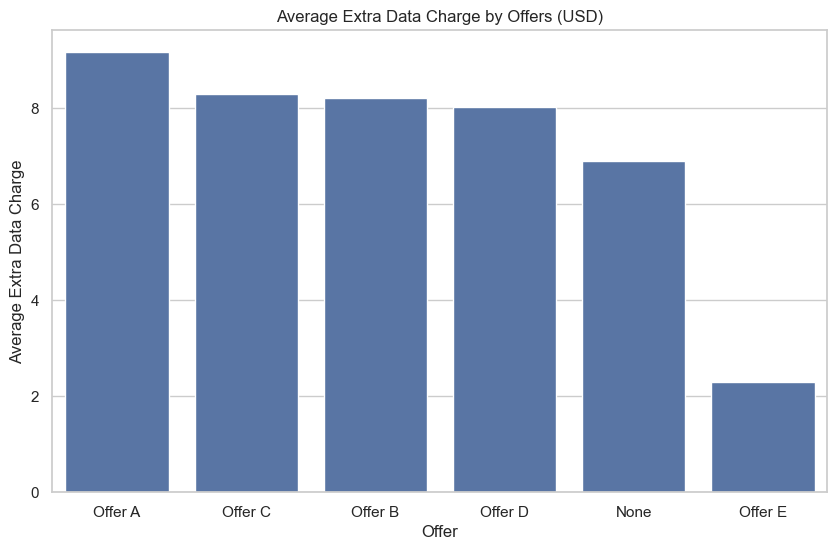

In [72]:
# average extra data charges by offer
source = frame.groupby('offer').agg(average_extra_data_charges=('total_extra_data_charges', 'mean')).sort_values(by='average_extra_data_charges', ascending=False).round(2).reset_index()
offerplot = sns.barplot(data=source, x='offer', y='average_extra_data_charges')
offerplot.set_title('Average Extra Data Charge by Offers (USD)')
offerplot.set_ylabel('Average Extra Data Charge')
offerplot.set_xlabel('Offer')

Data links Offer E and standard pricing to high churn risk, though pricing appears secondary. We will now examine 'superior competitor data' as another significant driver.

In [73]:
# number of customers using phone service
frame[frame['phone_service'] == True].shape[0]

6252

In [74]:
# number of customers using internet service
frame[frame['internet_service'] == True].shape[0]

5423

In [75]:
# percentage of customers with unlimited data when they use internet service
round(len(frame[frame['unlimited_data'] == True]) * 100 / len(frame[frame['internet_service'] == True]), 2)

86.02

In [76]:
# percentage of churned customers with unlimited data
round(len(churned[churned['unlimited_data'] == True]) * 100 / len(churned), 2)

80.48

In [77]:
# percentage of churned customers selected competitor offered more data option for churn reason despite having unlimited data
reason = 'Competitor offered more data'
round(len(churned[(churned['unlimited_data'] == True) & (churned['churn_reason'] == reason)]) * 100 / len(churned), 2)

5.11

Despite 80% of churned customers having unlimited data, "more data" remains a key churn reason. We must investigate competitor speed offers, network infrastructure, and pricing policies to identify the disconnect.

However, we don't have any competitor data.

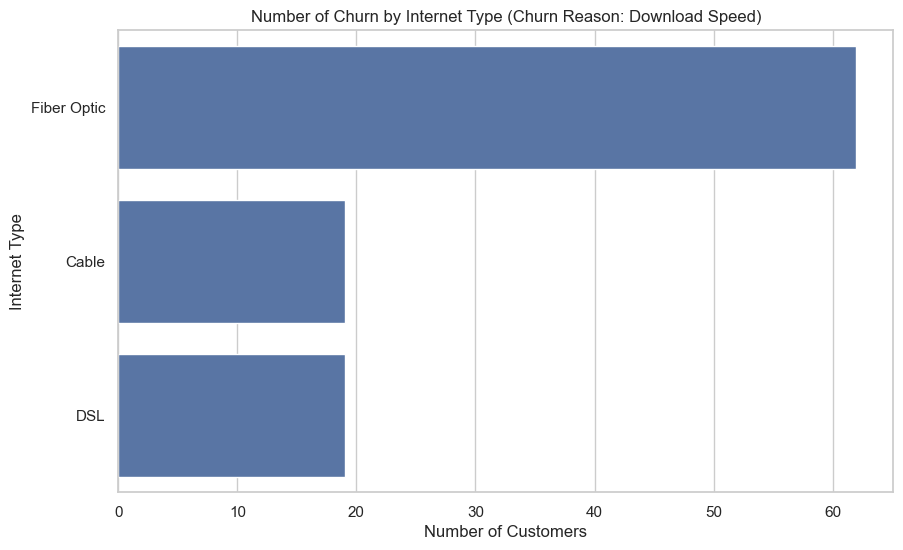

In [78]:
reason = 'Competitor offered higher download speeds'

source = churned[churned['churn_reason'] == reason].groupby('internet_type').agg(count=('age', 'count')).sort_values(by='count', ascending=False).reset_index()

typeplt = sns.barplot(data=source, y='internet_type', x='count')
typeplt.set_title('Number of Churn by Internet Type (Churn Reason: Download Speed)')
typeplt.set_ylabel('Internet Type')
typeplt.set_xlabel('Number of Customers')
plt.savefig('../data/graphs/by_internet_type.png', bbox_inches='tight', dpi=300)

The plot shows that download speed-related churn is concentrated among fiber optic users, suggesting infrastructural deficiencies in this service.

Text(0.5, 0, 'Percentage of Customers')

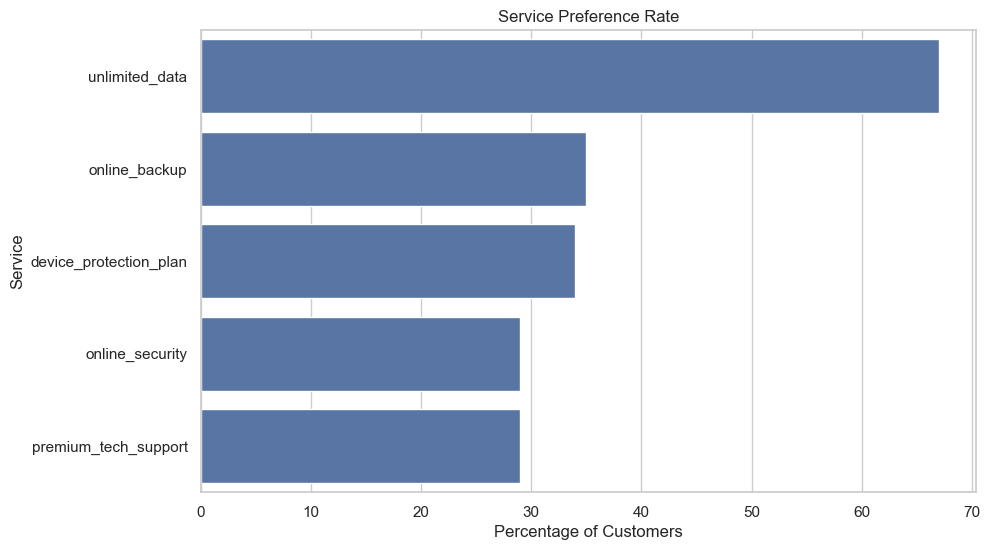

In [79]:
services = [
    'device_protection_plan',
    'online_security',
    'online_backup',
    'unlimited_data',
    'premium_tech_support'
]

pseudo = pd.DataFrame({'service': services})

pseudo['count'] = [
    round(
        frame[frame[service] == True].shape[0] * 100 / frame.shape[0]
    )
    for service in services
]

source = pseudo.sort_values(by='count', ascending=False)
serviceplt = sns.barplot(data=source, x='count', y='service')
serviceplt.set_title('Service Preference Rate')
serviceplt.set_ylabel('Service')
serviceplt.set_xlabel('Percentage of Customers')

Text(0.5, 0, 'Churn Rate')

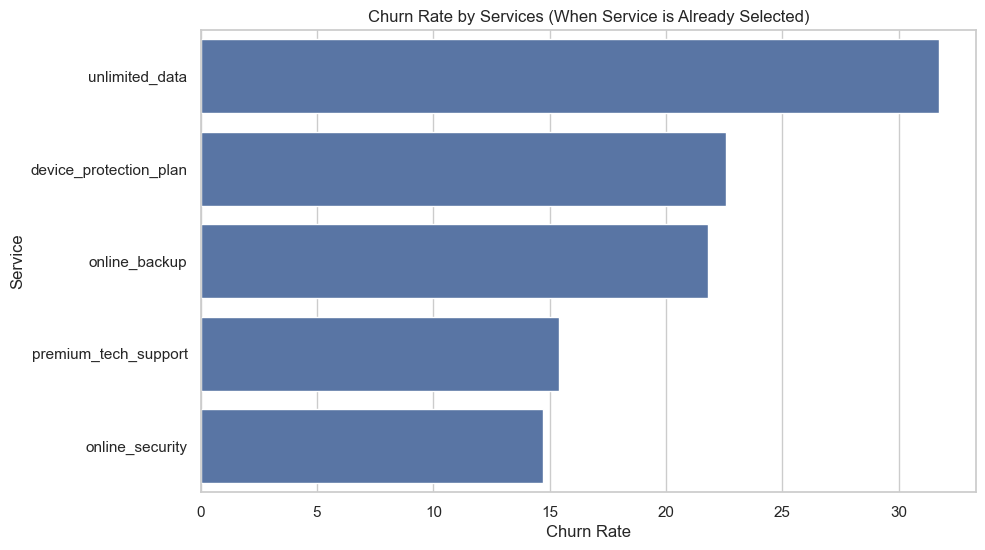

In [80]:
# identifying how many customers have churned by different options
pseudo = pd.DataFrame({'service': services})

pseudo['churn_rate'] = [
    round(
        frame.loc[(frame[service]) & (frame['customer_status'] == 'Churned')].shape[0]
        * 100
        / frame.loc[frame[service]].shape[0],
        2
    )
    for service in services
]

source = pseudo.sort_values(by='churn_rate', ascending=False)
serviceplt = sns.barplot(data=source, x='churn_rate', y='service')
serviceplt.set_title('Churn Rate by Services (When Service is Already Selected)')
serviceplt.set_ylabel('Service')
serviceplt.set_xlabel('Churn Rate')

In [81]:
# percentage of churns caused by communicational issues
comms = [
    'Poor expertise of phone support',
    'Poor expertise of online support',
    'Lack of self-service on Website',
    'Attitude of support person',
    'Attitude of service provider'
]

round(churned.loc[churned['churn_reason'].isin(comms)].shape[0] * 100 / churned.shape[0], 2)

20.55

In [82]:
# number of customers used premium tech support service but churned due to communicational issues
comms = [
    'Poor expertise of phone support',
    'Poor expertise of online support',
    'Lack of self-service on Website',
    'Attitude of support person',
    'Attitude of service provider'
]

round(churned.loc[(churned['premium_tech_support'] == True) & (churned['churn_reason'].isin(comms))].shape[0] * 100 / churned.shape[0], 2)

3.21

Analysis shows premium tech support is effective, yet communication issues drive 20% of churn. Unlimited data is the most popular service, while premium tech and online security see the lowest adoption rates.

Text(0, 0.5, 'Location')

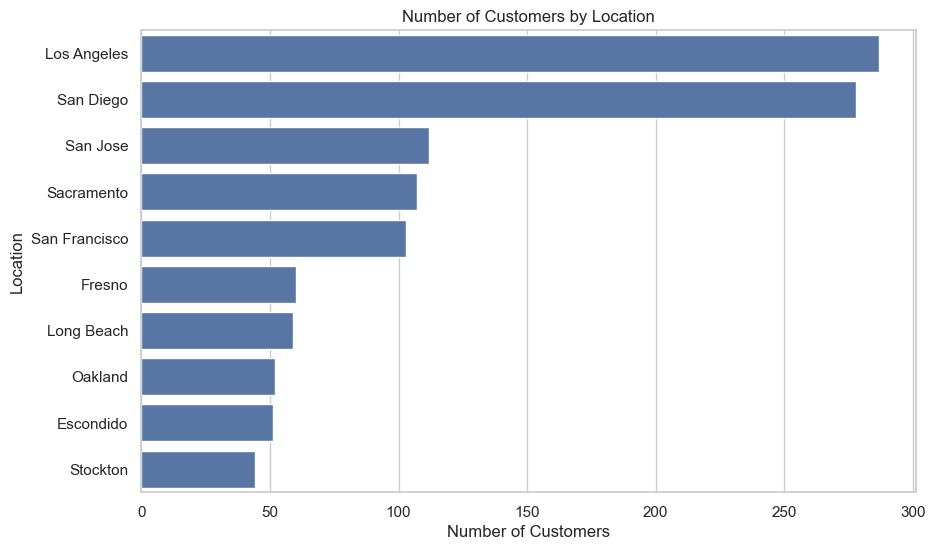

In [83]:
source = frame.groupby('city').agg(count=('age', 'count')).sort_values(by='count', ascending=False).reset_index().head(10)

cityplt = sns.barplot(data=source, y='city', x='count')
cityplt.set_title('Number of Customers by Location')
cityplt.set_xlabel('Number of Customers')
cityplt.set_ylabel('Location')

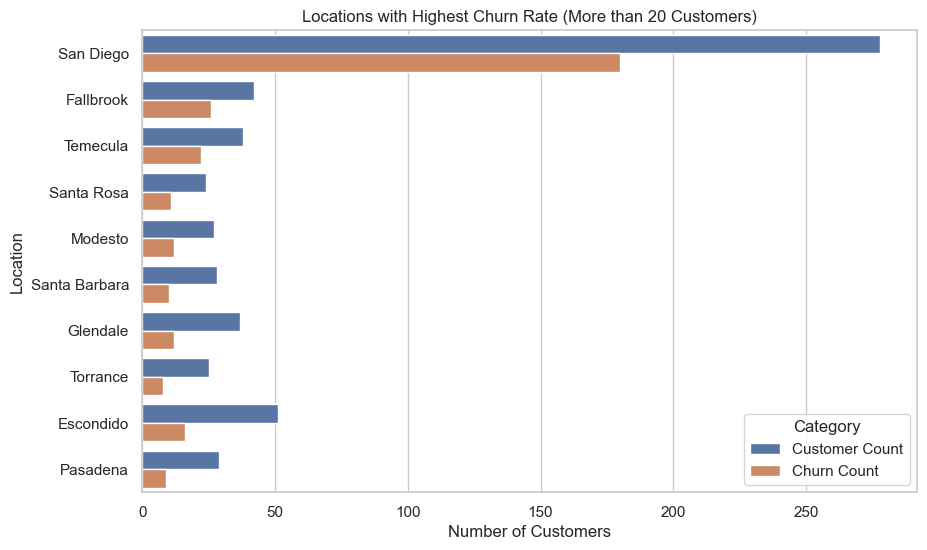

In [84]:
# number of total customers and churned customers by location ordered by churn rate
source = (
    frame.groupby('city')
    .agg(count=('age', 'count'))
    .merge(churned.groupby('city').agg(churn_count=('age', 'count')), on='city')
    .reset_index()
)

source['percentage'] = round(source['churn_count'] * 100 / source['count'], 2)

source = (
    source[source['count'] > 20]
    .sort_values(by='percentage', ascending=False)
    .head(10)
    .reset_index()
)

source = source.rename(columns={
    'churn_count': 'Churn Count',
    'count': 'Customer Count'
})

source = (
    source.melt(
        id_vars='city',
        value_vars=['Customer Count', 'Churn Count'],
        var_name='att',
        value_name='val'
    )
)

cityplt = sns.barplot(data=source, x='val', y='city', hue='att')
cityplt.set_title("Locations with Highest Churn Rate (More than 20 Customers)")
cityplt.set_ylabel('Location')
cityplt.set_xlabel('Number of Customers')
cityplt.legend(
    title='Category'
)
plt.savefig('../data/graphs/by_location.png', bbox_inches='tight', dpi=300)

In [85]:
# percentage of churn in San Diego
round(frame.loc[(frame['city'] == 'San Diego') & (frame['customer_status'] == 'Churned')].shape[0] * 100 / frame[frame['city'] == 'San Diego'].shape[0], 2)

64.75

Text(0.5, 0, 'Number of Customers')

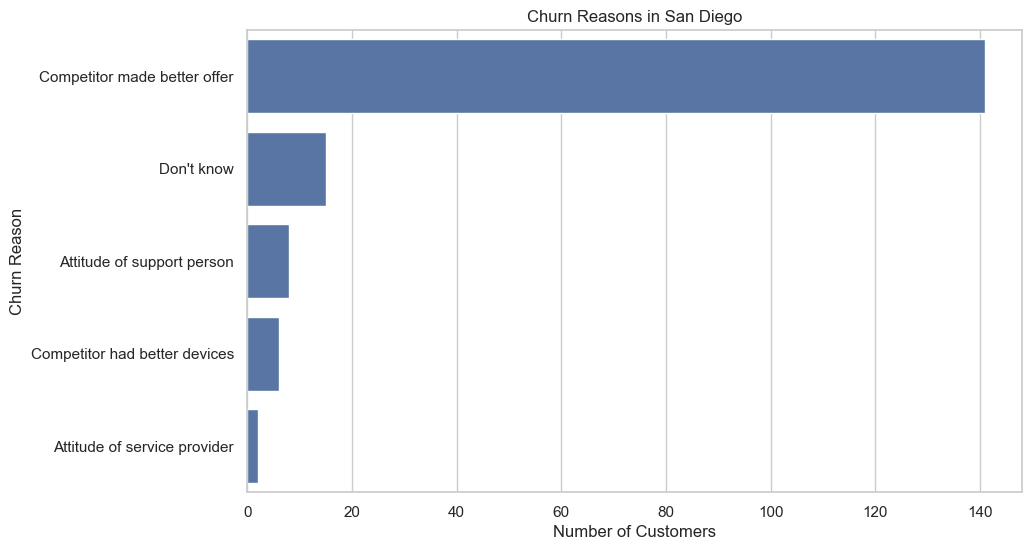

In [86]:
source = (
    churned[churned['city'] == 'San Diego']
    .groupby('churn_reason')
    .agg(count=('age', 'count'))
    .sort_values(by='count', ascending=False)
    .reset_index().head(5)
)

sanplot = sns.barplot(data=source, y='churn_reason', x='count')
sanplot.set_title('Churn Reasons in San Diego')
sanplot.set_ylabel('Churn Reason')
sanplot.set_xlabel('Number of Customers')

In [87]:
# percentage of churned customers from San Diego who had internet type Fiber Optic
round(len(churned.query("city == 'San Diego' & internet_type == 'Fiber Optic'")) * 100 / len(churned[churned['city'] == 'San Diego']), 2)

68.89

San Diego’s churn rate exceeds 65%, primarily driven by superior competitor offers. Despite 68% fiber optic adoption, 'Competitor offered higher download speeds' and 'Lack of affordable download/upload speed' are not a top-five churn reason, suggesting speed isn't the primary issue. Consequently, competitors likely offer more competitive pricing or superior network stability in the region.

In [88]:
# percentage of churned customers who extra data charge is applied
round(len(churned[churned['total_extra_data_charges'] > 0.0]) * 100 / len(churned), 2)

12.78

In [89]:
# average cost of unlimited data
float(round(churned[churned['unlimited_data'] == True]['monthly_charge'].mean() - churned[churned['unlimited_data'] == False]['monthly_charge'].mean(), 2))

18.77

In [90]:
# percentage of price related churn assuming 'Competitor made better offer' is about price
price_related = [
    'Competitor made better offer',
    'Long distance charges',
    'Price too high',
    'Extra data charges'
]

round(frame[frame['churn_reason'].isin(price_related)].shape[0] * 100 / churned.shape[0], 2)

26.32

While exhaustive price analysis is limited without competitor data, price-related factors drive nearly 26% of all churn.